query:  [ 0.00174778  0.41291198  0.70518255  0.93432791  1.0555235   1.05007311
  0.91623133  0.77093589  0.49627784  0.22255292 -0.12490222 -0.43367951
 -0.69018265 -0.87352781 -0.90922924 -0.92477211 -0.7395893  -0.53210142
 -0.26748003  0.04646493]
template:  [1.0312682  1.7341     2.02758026 1.88107074 1.37950387 0.74360897
 0.16433555 0.05164714 0.42738647 1.06916963]
cost:  20.0
query_ind:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
template_ind:  [0 0 0 0 0 0 0 0 0 0 0 1 2 3 4 5 6 7 8 9]

mapping:  {0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0], 6: [0], 7: [0], 8: [0], 9: [0], 10: [0], 11: [1], 12: [2], 13: [3], 14: [4], 15: [5], 16: [6], 17: [7], 18: [8], 19: [9]}
mapping:  {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 1: [11], 2: [12], 3: [13], 4: [14], 5: [15], 6: [16], 7: [17], 8: [18], 9: [19]}
Updated M: {(0, 1): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}


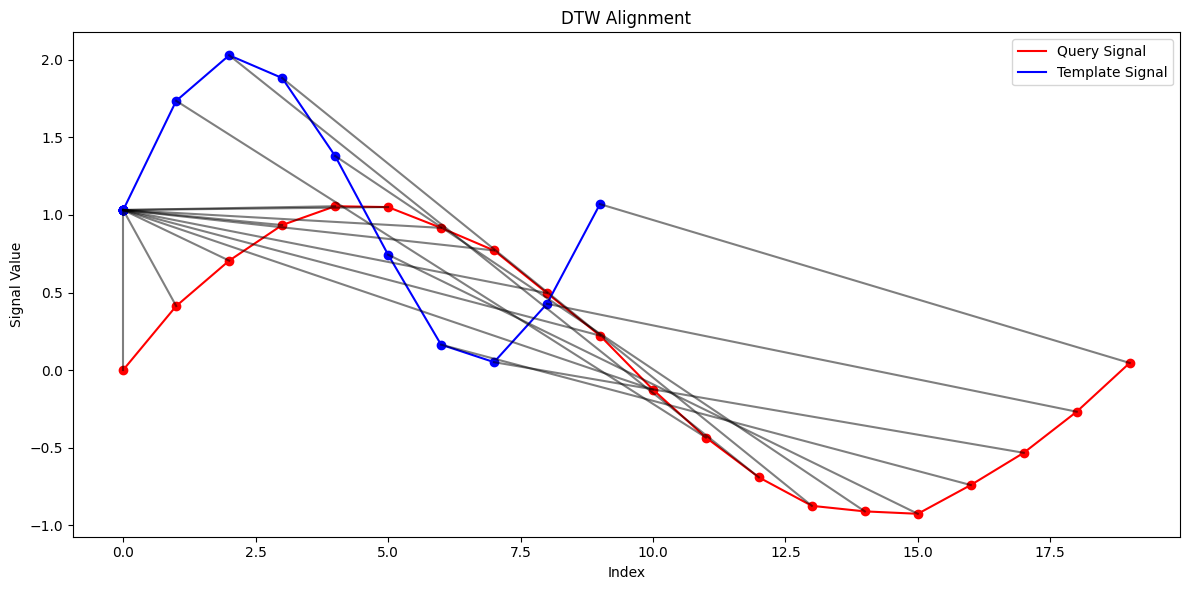

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from dtw import *
from copy import deepcopy


def maps(l1, l2):
    '''creates a dictionary where the unique elements of l1 become keys, 
    and their corresponding values are lists of elements from l2 
    THAT SHARE THE SAME INDEX...'''
    
    D = {}
    for i in range(len(l1)):
        if l1[i] not in D.keys():
            D[l1[i]] = []

        D[l1[i]].append(l2[i])

    return D


def viz(Q, T, ind1, ind2, fname):
    # Convert to numpy arrays for ease of indexing
    Q = np.array(Q)
    T = np.array(T)

    # Plot the query and template signals with alignment lines
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(Q)), Q, 'r-', label='Query Signal')
    plt.plot(range(len(T)), T, 'b-', label='Template Signal')

    # Plot the alignment lines
    for i, j in zip(ind1, ind2):
        plt.plot([i, j], [Q[i], T[j]], 'k-', alpha=0.5)

    plt.scatter(ind1, Q[ind1], color='red')
    plt.scatter(ind2, T[ind2], color='blue')

    # Labeling the plot
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.title('DTW Alignment')

    plt.tight_layout()
    plt.savefig(fname, dpi = 300)
    plt.show()


def compute_missing_ranges(M, D):
    """
    Compute the missing ranges in M based on D.

    Parameters:
    - M: Dictionary where keys are tuples representing pairs of indices and values are lists to store ranges.
    - D: Dictionary where keys are indices and values are lists of indices from another list.

    Returns:
    - Updated M dictionary with computed ranges appended to each key's list.
    """

    for p in M:

        start = min(D[p[0]]) + 1
        end = max(D[p[1]])
        M[p].extend([r for r in range(start, end)])

    return M


# # Example usage:
# M_1 = {(1, 2): []}
# D_1_2 = {1: [2], 2: [5]}

# List 1
idx1 = np.linspace(0, 6.28, num = 20)
query = np.sin(idx1) + np.random.uniform(size = 20)/10.0

# List 2 [USE any one of the options]
# Option 1.
# idx2 = np.linspace(0, 6.28, num = 100)
# template = np.cos(idx2)
# print (template)

# Option 2.
idx2 = np.linspace(0, 6.28, num = 10)
template = np.sin(idx2) + np.random.uniform(size = 10)/10.0 + 1

# Define the distance metric (e.g., Euclidean distance)
dist = lambda x, y: 0 if x == y else 1

# Find the best match with the canonical recursion formula
alignment = dtw(query, template, dist)
cost, _, _, (query_ind, template_ind) = deepcopy(alignment)


print('query: ', query)
print('template: ', template)

print('cost: ', cost)
print ('query_ind: ', query_ind)
print ("template_ind: ", template_ind)

print()

dic_qt = maps(query_ind, template_ind)
print ('mapping: ', dic_qt)

dic_tq = maps(template_ind, query_ind)
print ('mapping: ', dic_tq)

# # Example usage:
M_1 = {(0, 1): []}
# D_1_2 = {1: [2], 2: [5]}

M_1 = compute_missing_ranges(deepcopy(M_1), deepcopy(dic_tq))
print("Updated M:", M_1)

viz(query, template, query_ind, template_ind, 'DTW_Render.png')